## Business Understanding

### Objective
The objective is to forecast product demand for each supermarket-SKU combination eight weeks ahead. Accurate forecasts help reduce stock-outs while minimizing excess inventory and write-offs.

### Available Data
- Historical daily demand
- Promotional periods

### Deliverables
- Explore and understand the data
- Build a forecasting model
- Evaluate model performance
- Present business insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
demand = pd.read_csv("demand.csv", parse_dates=["date"])
promotions = pd.read_csv("promotions.csv", parse_dates=["promotion_date"])

In [3]:
demand.head()

,date,demand,sku,supermarket
0,2019-01-01,93.0,Organic Milk,FreshMart
1,2019-01-02,93.0,Organic Milk,FreshMart
2,2019-01-03,94.0,Organic Milk,FreshMart
3,2019-01-04,95.0,Organic Milk,FreshMart
4,2019-01-05,92.0,Organic Milk,FreshMart


In [4]:
promotions.head()

,Unnamed: 0,promotion_date,sku,supermarket
0,0,2020-09-26,Organic Milk,DailyNeeds
1,1,2019-09-18,Organic Milk,DailyNeeds
2,2,2021-09-28,Organic Milk,DailyNeeds
3,3,2021-02-11,Organic Milk,DailyNeeds
4,0,2021-10-03,Organic Milk,GreenBasket


In [5]:
print("Demand Shape:", demand.shape)
print("Promotions Shape:", promotions.shape)

Demand Shape: (9855, 4)
Promotions Shape: (15, 4)


It can be seen from here that Demand occurs for daily sales ,and promotion is a rare event 

In [6]:
demand.info()

print()

promotions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9855 entries, 0 to 9854
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         9855 non-null   datetime64[ns]
 1   demand       8738 non-null   float64       
 2   sku          9855 non-null   object        
 3   supermarket  9855 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 308.1+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Unnamed: 0      15 non-null     int64         
 1   promotion_date  15 non-null     datetime64[ns]
 2   sku             15 non-null     object        
 3   supermarket     15 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 612.0+ bytes


In [7]:
print(demand.isnull().sum())

print()

print(promotions.isnull().sum())

date              0
demand         1117
sku               0
supermarket       0
dtype: int64

Unnamed: 0        0
promotion_date    0
sku               0
supermarket       0
dtype: int64


<h5>Let's check weather the demand value is missing regularly because of some events or it's just a dataset collecting problem</h5>

In [8]:
missing_percentage = demand["demand"].isnull().mean() * 100
print(f"Missing Percentage: {missing_percentage:.2f}%")

Missing Percentage: 11.33%


In [9]:
missing_demand = demand[demand["demand"].isnull()]
missing_demand.head(10)

,date,demand,sku,supermarket
10,2019-01-11,NaN,Organic Milk,FreshMart
11,2019-01-12,NaN,Organic Milk,FreshMart
35,2019-02-05,NaN,Organic Milk,FreshMart
43,2019-02-13,NaN,Organic Milk,FreshMart
65,2019-03-07,NaN,Organic Milk,FreshMart
74,2019-03-16,NaN,Organic Milk,FreshMart
85,2019-03-27,NaN,Organic Milk,FreshMart
92,2019-04-03,NaN,Organic Milk,FreshMart
96,2019-04-07,NaN,Organic Milk,FreshMart
99,2019-04-10,NaN,Organic Milk,FreshMart


Missing Values are not consecutive and are from same supermarket let's confirm our hypothesis

In [10]:
missing_demand.groupby("sku").size()

sku
Free Range Eggs      368
Organic Milk         391
Whole Wheat Bread    358
dtype: int64

In [11]:
missing_demand.groupby("supermarket").size()

supermarket
DailyNeeds     323
FreshMart      393
GreenBasket    401
dtype: int64

So Missing values occur across all supermarkets and sku so let's move on to Are these values missing randomly, or do they follow a pattern over time

In [12]:
missing_demand = demand[demand["demand"].isnull()].copy()
missing_demand["date"] = pd.to_datetime(missing_demand["date"])
missing_demand.sort_values("date").head(15)

,date,demand,sku,supermarket
5476,2019-01-02,NaN,Whole Wheat Bread,GreenBasket
6571,2019-01-02,NaN,Free Range Eggs,FreshMart
2192,2019-01-03,NaN,Organic Milk,GreenBasket
2193,2019-01-04,NaN,Organic Milk,GreenBasket
7669,2019-01-05,NaN,Free Range Eggs,DailyNeeds
5480,2019-01-06,NaN,Whole Wheat Bread,GreenBasket
4386,2019-01-07,NaN,Whole Wheat Bread,DailyNeeds
8766,2019-01-07,NaN,Free Range Eggs,GreenBasket
6578,2019-01-09,NaN,Free Range Eggs,FreshMart
2198,2019-01-09,NaN,Organic Milk,GreenBasket


In [13]:
missing_demand["date"].min(), missing_demand["date"].max()

(Timestamp('2019-01-02 00:00:00'), Timestamp('2021-12-30 00:00:00'))

The missing values occur throughout the entire dataset, not just during one bad month or one store

In [14]:
#statistics
demand["demand"].describe()

count    8738.000000
mean       74.240764
std        24.354299
min        10.000000
25%        57.000000
50%        70.000000
75%        93.000000
max       485.000000
Name: demand, dtype: float64

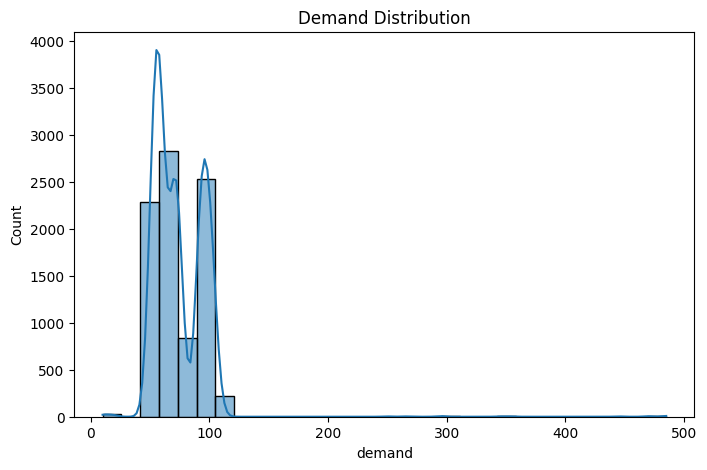

In [15]:
# Distribution
plt.figure(figsize=(8,5))
sns.histplot(demand["demand"], bins=30, kde=True)
plt.title("Demand Distribution")
plt.show()

The average daily demand is approximately 74 units, while the median demand is 70 units, indicating a slightly right-skewed distribution. Most demand observations lie between 50 and 100 units. However, a small number of unusually high demand values (up to 485 units) are present, suggesting potential outliers. These extreme values may represent genuine demand spikes, such as promotional periods, and therefore should be investigated before considering any outlier treatment.

In [16]:
# Highest demand records
demand.nlargest(10, "demand")

,date,demand,sku,supermarket
1237,2019-05-23,485.0,Organic Milk,DailyNeeds
1475,2020-01-16,485.0,Organic Milk,DailyNeeds
1522,2020-03-03,485.0,Organic Milk,DailyNeeds
1838,2021-01-13,485.0,Organic Milk,DailyNeeds
2165,2021-12-06,485.0,Organic Milk,DailyNeeds
29,2019-01-30,470.0,Organic Milk,FreshMart
659,2020-10-21,470.0,Organic Milk,FreshMart
819,2021-03-30,470.0,Organic Milk,FreshMart
6102,2020-09-19,445.0,Whole Wheat Bread,GreenBasket
6557,2021-12-18,445.0,Whole Wheat Bread,GreenBasket


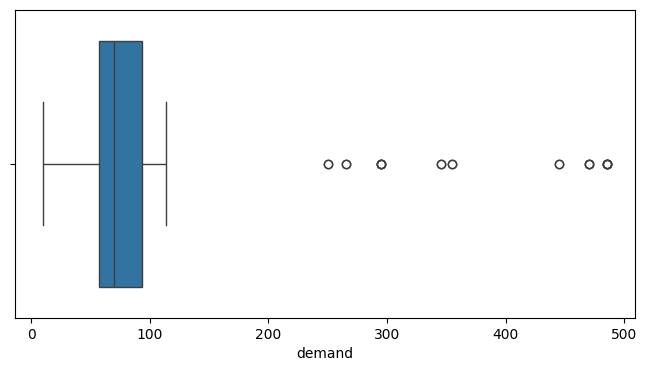

In [17]:
# Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=demand["demand"])
plt.show()

In [18]:
demand["date"] = pd.to_datetime(demand["date"])
demand["date"].dtype

dtype('<M8[ns]')

<h4>Let's do EDA for more understanding</h4>


In [19]:
# SKU
display(
    demand.groupby("sku")["demand"]
    .agg(["mean","median","std"])
    .sort_values("mean",ascending=False)
)

,mean,median,std
sku,,,
Organic Milk,84.793296,96.0,31.139550
Free Range Eggs,69.356599,70.0,14.889818
Whole Wheat Bread,68.674684,58.0,20.651599


In [20]:
# Supermarket
display(
    demand.groupby("supermarket")["demand"]
    .agg(["mean","median","std"])
    .sort_values("mean",ascending=False)
)

,mean,median,std
supermarket,,,
DailyNeeds,77.651384,71.0,26.603059
GreenBasket,73.476768,74.0,21.397011
FreshMart,71.509474,62.0,24.313358


sku,Free Range Eggs,Organic Milk,Whole Wheat Bread
supermarket,,,
DailyNeeds,71.420266,102.705068,57.195412
FreshMart,62.505510,97.829279,55.612004
GreenBasket,74.250208,52.324814,92.887107


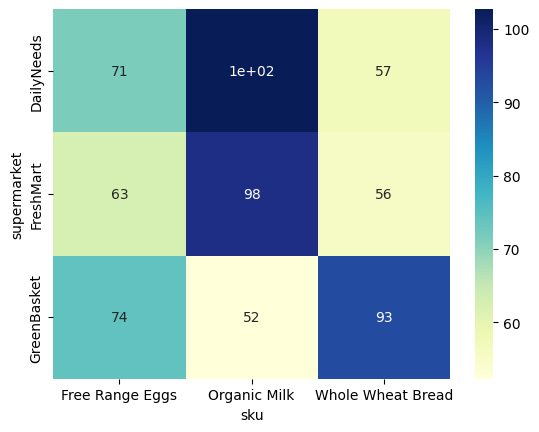

In [21]:
pivot = demand.pivot_table(
    values="demand",
    index="supermarket",
    columns="sku",
    aggfunc="mean"
)

display(pivot)

sns.heatmap(pivot,annot=True,cmap="YlGnBu")
plt.show()

Demand varies substantially across supermarket–SKU combinations, indicating that both store characteristics and product type significantly influence sales. This suggests that supermarket and SKU should be important &  included as predictive features during model development.

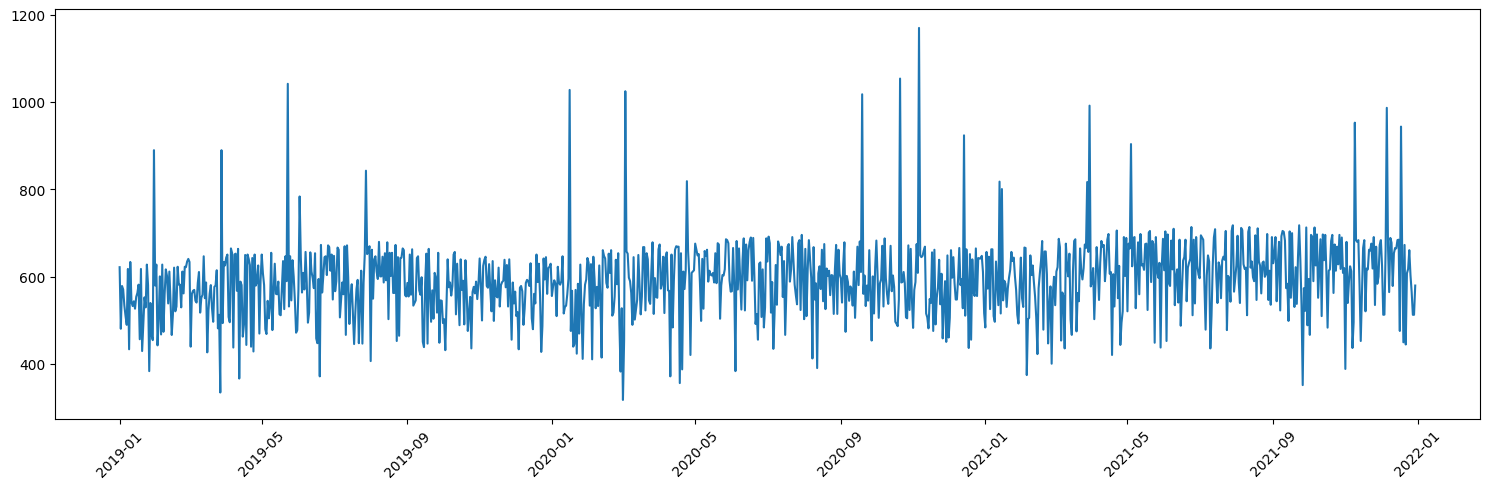

In [22]:
#Trend
plt.figure(figsize=(15,5))

daily = demand.groupby("date")["demand"].sum()

plt.plot(daily)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Rolling Average

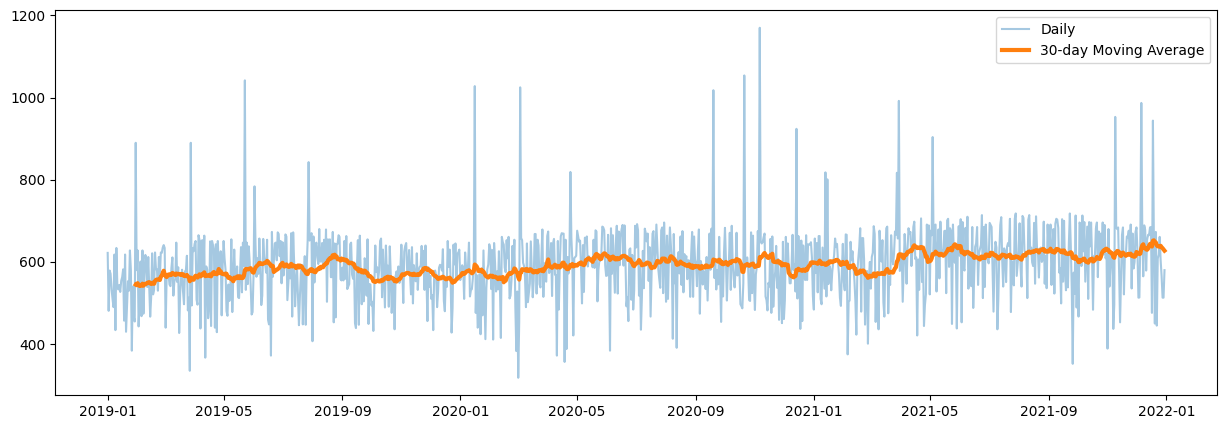

In [23]:
daily = demand.groupby("date")["demand"].sum()

rolling = daily.rolling(30).mean()

plt.figure(figsize=(15,5))

plt.plot(daily,label="Daily",alpha=0.4)

plt.plot(rolling,label="30-day Moving Average",linewidth=3)

plt.legend()

plt.show()

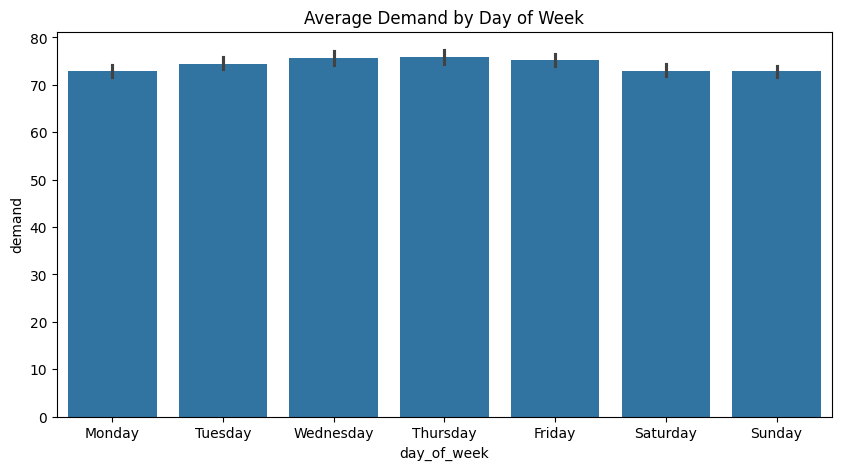

In [24]:
demand["day_of_week"] = demand["date"].dt.day_name()

order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

plt.figure(figsize=(10,5))
sns.barplot(
    data=demand,
    x="day_of_week",
    y="demand",
    order=order,
    estimator="mean"
)
plt.title("Average Demand by Day of Week")
plt.show()

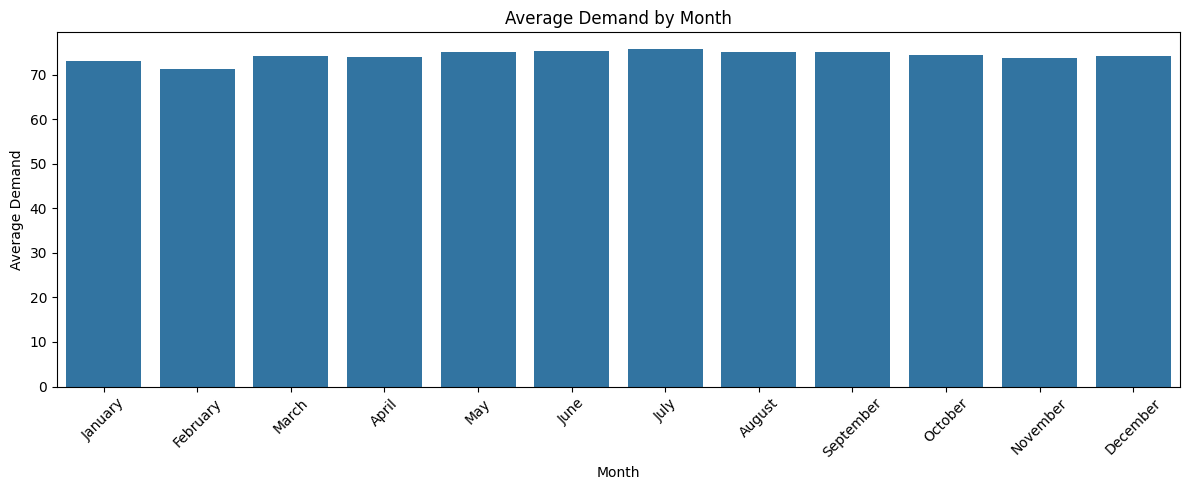

In [25]:
#Monthly seasonality 
demand["month"] = demand["date"].dt.month_name()

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

plt.figure(figsize=(12,5))

sns.barplot(
    data=demand,
    x="month",
    y="demand",
    order=month_order,
    estimator="mean",
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.tight_layout()
plt.show()

The demand remains relatively stable across daily, weekly, and monthly time periods. While occasional short-term demand spikes are observed, there is no significant long-term trend or strong weekly or monthly seasonality. This suggests that temporal factors have a limited influence on demand, whereas other factors such as supermarket, SKU, and promotions are likely to play a more significant role in forecasting.

<h3> Merging both demand and promotion dataset</h3>

In [26]:
promotions.drop(columns=["Unnamed: 0"], inplace=True, errors="ignore")
promotions["is_promotion"] = 1

In [27]:
demand = demand.merge(
    promotions,
    left_on=["date", "supermarket", "sku"],
    right_on=["promotion_date", "supermarket", "sku"],
    how="left"
)

In [28]:
demand["is_promotion"] = demand["is_promotion"].fillna(0).astype(int)

In [29]:
demand.drop(columns=["promotion_date"], inplace=True)

In [30]:
demand.head()

,date,demand,sku,supermarket,day_of_week,month,is_promotion
0,2019-01-01,93.0,Organic Milk,FreshMart,Tuesday,January,0
1,2019-01-02,93.0,Organic Milk,FreshMart,Wednesday,January,0
2,2019-01-03,94.0,Organic Milk,FreshMart,Thursday,January,0
3,2019-01-04,95.0,Organic Milk,FreshMart,Friday,January,0
4,2019-01-05,92.0,Organic Milk,FreshMart,Saturday,January,0


In [31]:
print(demand["is_promotion"].value_counts())

is_promotion
0    9840
1      15
Name: count, dtype: int64


In [32]:
promotion_summary = demand.groupby("is_promotion")["demand"].agg(
    ["count", "mean", "median", "std"]
)

display(promotion_summary)

,count,mean,median,std
is_promotion,,,,
0,8725,74.236653,70.0,24.361503
1,13,77.000000,67.0,19.472202


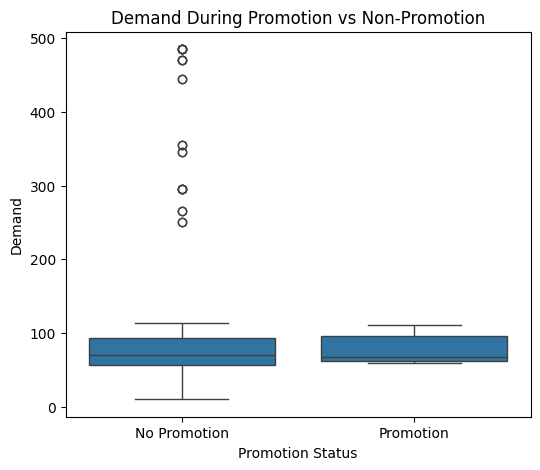

In [33]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=demand,
    x="is_promotion",
    y="demand"
)

plt.xticks([0,1], ["No Promotion","Promotion"])
plt.title("Demand During Promotion vs Non-Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Demand")
plt.show()

In [34]:
# Promotion lift per SKU
promo_impact = demand.groupby(['sku', 'is_promotion'])['demand'].mean().unstack()
promo_impact.columns = ['No Promo', 'Promo']
promo_impact['Lift %'] = ((promo_impact['Promo'] - promo_impact['No Promo']) / promo_impact['No Promo'] * 100).round(1)
promo_impact = promo_impact.round(2)
display(promo_impact)

,No Promo,Promo,Lift %
sku,,,
Free Range Eggs,69.35,72.67,4.8
Organic Milk,84.79,92.33,8.9
Whole Wheat Bread,68.67,72.29,5.3


#### Promotion Lift Findings
Promotions drive a modest but consistent demand lift across all three SKUs:
- Organic Milk sees the strongest response at 8.9% uplift
- Whole Wheat Bread at 5.3% and Free Range Eggs at 4.8% show smaller but real lifts

However, with only 13 promotion events in the dataset, these estimates are 
statistically weak  a few unusual days could be inflating or deflating these 
numbers. The direction is reliable; the magnitude should be treated with caution 
until more promotion data is collected.

<h3>Now we got to know everything and relationship with data let's move for feature engineering and handle missing data and more</h3>

Handling Missing values

In [35]:

demand = demand.sort_values(["supermarket", "sku", "date"])


demand["demand"] = (
    demand.groupby(["supermarket", "sku"])["demand"]
          .transform(lambda x: x.interpolate(method="linear"))
)

# Fill remaining missing values at the start/end
demand["demand"] = (
    demand.groupby(["supermarket", "sku"])["demand"]
          .transform(lambda x: x.ffill().bfill())
)

In [36]:
print(demand["demand"].isnull().sum())

0


In [37]:
#Calendar Features
demand["year"] = demand["date"].dt.year
demand["month_num"] = demand["date"].dt.month
demand["day"] = demand["date"].dt.day
demand["day_of_week"] = demand["date"].dt.dayofweek
demand["week"] = demand["date"].dt.isocalendar().week.astype(int)

In [38]:
#Lag Features

demand = demand.sort_values(["supermarket", "sku", "date"])

demand["lag_1"]  = demand.groupby(["supermarket","sku"])["demand"].shift(1)
demand["lag_7"]  = demand.groupby(["supermarket","sku"])["demand"].shift(7)
demand["lag_14"] = demand.groupby(["supermarket","sku"])["demand"].shift(14)
demand["lag_21"] = demand.groupby(["supermarket","sku"])["demand"].shift(21)
demand["lag_28"] = demand.groupby(["supermarket","sku"])["demand"].shift(28)
demand["lag_56"] = demand.groupby(["supermarket","sku"])["demand"].shift(56)
demand["lag_30"] = demand.groupby(["supermarket","sku"])["demand"].shift(30)

In [39]:
#Rolling statistics + new engineered features

demand["rolling_mean_7"]  = demand.groupby(["supermarket","sku"])["demand"].transform(lambda x: x.shift(1).rolling(7).mean())
demand["rolling_mean_14"] = demand.groupby(["supermarket","sku"])["demand"].transform(lambda x: x.shift(1).rolling(14).mean())
demand["rolling_mean_28"] = demand.groupby(["supermarket","sku"])["demand"].transform(lambda x: x.shift(1).rolling(28).mean())
demand["rolling_mean_30"] = demand.groupby(["supermarket","sku"])["demand"].transform(lambda x: x.shift(1).rolling(30).mean())
demand["rolling_std_7"]   = demand.groupby(["supermarket","sku"])["demand"].transform(lambda x: x.shift(1).rolling(7).std())
demand["rolling_std_14"]  = demand.groupby(["supermarket","sku"])["demand"].transform(lambda x: x.shift(1).rolling(14).std())

# Demand range
demand["rolling_max_7"]   = demand.groupby(["supermarket","sku"])["demand"].transform(lambda x: x.shift(1).rolling(7).max())
demand["rolling_min_7"]   = demand.groupby(["supermarket","sku"])["demand"].transform(lambda x: x.shift(1).rolling(7).min())
demand["rolling_range_7"] = demand["rolling_max_7"] - demand["rolling_min_7"]


demand["lag1_vs_mean7"]  = demand["lag_1"]  / (demand["rolling_mean_7"]  + 1)
demand["lag7_vs_mean28"] = demand["lag_7"]  / (demand["rolling_mean_28"] + 1)


sku_mean   = demand.groupby("sku")["demand"].transform("mean")
super_mean = demand.groupby("supermarket")["demand"].transform("mean")
demand["sku_avg_demand"]   = sku_mean
demand["super_avg_demand"] = super_mean

In [40]:
demand.isnull().sum()

date                  0
demand                0
sku                   0
supermarket           0
day_of_week           0
month                 0
is_promotion          0
year                  0
month_num             0
day                   0
week                  0
lag_1                 9
lag_7                63
lag_14              126
lag_21              189
lag_28              252
lag_56              504
lag_30              270
rolling_mean_7       63
rolling_mean_14     126
rolling_mean_28     252
rolling_mean_30     270
rolling_std_7        63
rolling_std_14      126
rolling_max_7        63
rolling_min_7        63
rolling_range_7      63
lag1_vs_mean7        63
lag7_vs_mean28      252
sku_avg_demand        0
super_avg_demand      0
dtype: int64

In [41]:
demand = demand.dropna().reset_index(drop=True)

In [42]:
print(demand.shape)
demand.head()

(9351, 31)


,date,demand,sku,supermarket,day_of_week,month,is_promotion,year,month_num,day,...,rolling_mean_30,rolling_std_7,rolling_std_14,rolling_max_7,rolling_min_7,rolling_range_7,lag1_vs_mean7,lag7_vs_mean28,sku_avg_demand,super_avg_demand
0,2019-02-26,66.0,Free Range Eggs,DailyNeeds,1,February,0,2019,2,26,...,66.866667,2.138090,1.549991,71.0,65.0,6.0,0.960499,0.983744,69.374916,77.103744
1,2019-02-27,70.0,Free Range Eggs,DailyNeeds,2,February,0,2019,2,27,...,66.933333,2.225395,1.595409,71.0,65.0,6.0,0.962500,1.042202,69.374916,77.103744
2,2019-02-28,70.0,Free Range Eggs,DailyNeeds,3,February,0,2019,2,28,...,67.166667,1.988060,1.737198,70.0,65.0,5.0,1.022965,1.026447,69.374916,77.103744
3,2019-03-01,70.0,Free Range Eggs,DailyNeeds,4,March,0,2019,3,1,...,67.316667,1.988060,1.847556,70.0,65.0,5.0,1.022965,0.996076,69.374916,77.103744
4,2019-03-02,67.0,Free Range Eggs,DailyNeeds,5,March,0,2019,3,2,...,67.383333,2.214670,1.865314,70.0,65.0,5.0,1.018711,0.980915,69.374916,77.103744


<h3>Lets move to model - baseline + optimal </h3>

In [43]:
FORECAST_HORIZON = 56

demand = demand.sort_values(["supermarket", "sku", "date"])

demand["target"] = demand.groupby(
    ["supermarket", "sku"]
)["demand"].shift(-FORECAST_HORIZON)

In [44]:
demand = demand.dropna(subset=["target"]).reset_index(drop=True)

In [45]:
X = demand.drop(columns=["target", "demand", "date"])
y = demand["target"]

In [46]:

cols_to_drop = [c for c in ["day_of_week", "month"] if c in X.columns and X[c].dtype == object]
X = X.drop(columns=cols_to_drop)

X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)  
print(f"Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features")
print(list(X.columns))

Feature matrix: 8,847 rows × 30 features
['day_of_week', 'is_promotion', 'year', 'month_num', 'day', 'week', 'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_56', 'lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_14', 'rolling_max_7', 'rolling_min_7', 'rolling_range_7', 'lag1_vs_mean7', 'lag7_vs_mean28', 'sku_avg_demand', 'super_avg_demand', 'sku_Organic Milk', 'sku_Whole Wheat Bread', 'supermarket_FreshMart', 'supermarket_GreenBasket']


In [47]:
# Split by date so every SKU gets a proper chronological train/test boundary

dates = demand["date"].sort_values().unique()
cutoff_date = dates[int(len(dates) * 0.8)]
print(f"Cutoff date: {cutoff_date}")
print(f"Train: up to {cutoff_date} | Test: after {cutoff_date}")

train_mask = demand["date"] <= cutoff_date
test_mask  = demand["date"] >  cutoff_date

X_train = X[train_mask].reset_index(drop=True)
X_test  = X[test_mask].reset_index(drop=True)
y_train = y[train_mask].reset_index(drop=True)
y_test  = y[test_mask].reset_index(drop=True)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

Cutoff date: 2021-04-22 00:00:00
Train: up to 2021-04-22 00:00:00 | Test: after 2021-04-22 00:00:00
X_train: (7083, 30) | X_test: (1764, 30)


<h2>Random Forest</h2>

In [48]:
from sklearn.ensemble import RandomForestRegressor



rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 :", rf_r2)

Random Forest
MAE : 3.1053826931727206
RMSE: 15.393435540457547
R2 : 0.5935129884725918


<h3>XGBOOST</h3>

In [50]:
# NOTE: lag_56 and lag_14 are now computed earlier in the Lag Features cell

print("lag_56 in features:", "lag_56" in X_train.columns)
print("lag_14 in features:", "lag_14" in X_train.columns)

lag_56 in features: True
lag_14 in features: True


In [51]:
# NOTE: rolling_mean_14 and rolling_std_7 are now computed earlier

print("rolling_mean_14 in features:", "rolling_mean_14" in X_train.columns)
print("rolling_std_7 in features:",   "rolling_std_7"   in X_train.columns)

rolling_mean_14 in features: True
rolling_std_7 in features: True


In [52]:
from xgboost import XGBRegressor


xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric="mae"
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(f"Best iteration: {xgb.best_iteration}")
xgb_pred = xgb.predict(X_test)

Best iteration: 113


In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R²  :", r2_score(y_test, xgb_pred))

MAE : 3.572045906366765
RMSE: 15.542346984386807
R²  : 0.5856104842036286


<h3>LightGBM :Additional Model</h3>

LightGBM is often faster and can outperform XGBoost on tabular data with many features.
Included here for direct comparison.

In [54]:



    import lightgbm as lgb

    lgbm = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    lgbm.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
    )

    lgbm_pred = lgbm.predict(X_test)

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    lgbm_mae  = mean_absolute_error(y_test, lgbm_pred)
    lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))
    lgbm_r2   = r2_score(y_test, lgbm_pred)

    print("LightGBM")
    print("MAE :", round(lgbm_mae,  4))
    print("RMSE:", round(lgbm_rmse, 4))
    print("R²  :", round(lgbm_r2,   4))



LightGBM
MAE : 3.4919
RMSE: 15.4763
R²  : 0.5891


<h3>Ensemble : Averaging RF + XGBoost + Lightbgm</h3>

Averaging predictions from multiple models (ensemble) reduces variance and
typically outperforms any single model, especially when RF and XGBoost disagree.

In [55]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

if lgbm_pred is not None:
    ensemble_pred = (rf_pred + xgb_pred + lgbm_pred) / 3
else:
    ensemble_pred = (rf_pred + xgb_pred) / 2

ens_mae  = mean_absolute_error(y_test, ensemble_pred)
ens_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
ens_r2   = r2_score(y_test, ensemble_pred)

print("Ensemble (average)")
print("MAE :", round(ens_mae,  4))
print("RMSE:", round(ens_rmse, 4))
print("R²  :", round(ens_r2,   4))

Ensemble (average)
MAE : 3.2768
RMSE: 15.4203
R²  : 0.5921


<h3>Let's Test it on Prophet</h3>

In [56]:
from prophet import Prophet

series = demand[
    (demand["supermarket"]=="FreshMart") &
    (demand["sku"]=="Organic Milk")
][["date","demand"]]

series = series.rename(columns={
    "date":"ds",
    "demand":"y"
})

series.head()

,ds,y
3932,2019-02-26,92.0
3933,2019-02-27,94.0
3934,2019-02-28,93.0
3935,2019-03-01,93.0
3936,2019-03-02,91.0


In [57]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(series)

08:19:01 - cmdstanpy - INFO - Chain [1] start processing
08:19:01 - cmdstanpy - INFO - Chain [1] done processing


In [58]:
future = model.make_future_dataframe(
    periods=56
)

forecast = model.predict(future)

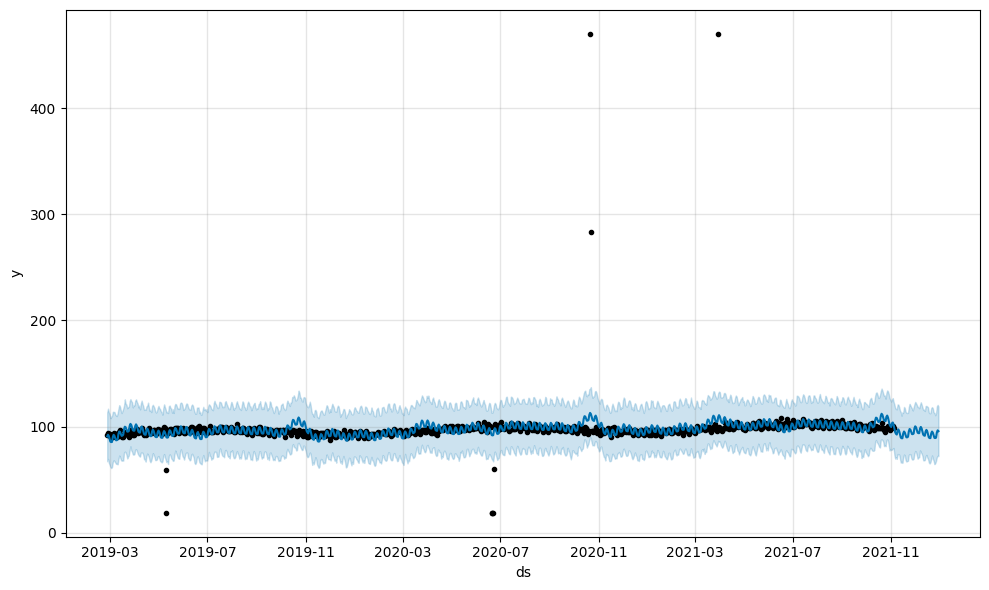

In [59]:
fig = model.plot(forecast)

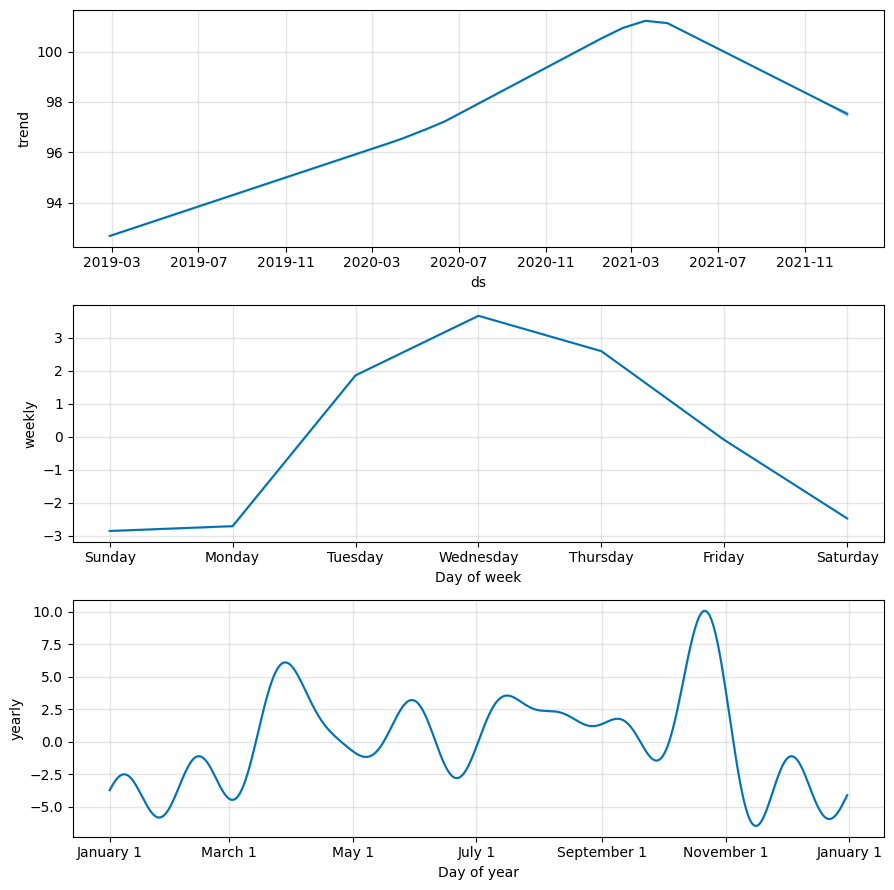

In [60]:
fig2 = model.plot_components(forecast)

In [61]:
train = series.iloc[:-56]

test = series.iloc[-56:]

In [62]:
model = Prophet()

model.fit(train)

08:19:04 - cmdstanpy - INFO - Chain [1] start processing
08:19:04 - cmdstanpy - INFO - Chain [1] done processing


In [63]:
future = model.make_future_dataframe(periods=56)

forecast = model.predict(future)

In [64]:
pred = forecast.tail(56)["yhat"].values

In [65]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(test["y"], pred)

rmse = np.sqrt(
    mean_squared_error(test["y"], pred)
)

print(mae)
print(rmse)

8.290419107697062
10.762043866734025


,Model,MAE,RMSE,R2
0,Random Forest,3.1054,15.3934,0.5935
1,XGBoost,3.5720,15.5423,0.5856
2,LightGBM,3.4919,15.4763,0.5891
3,Ensemble,3.2768,15.4203,0.5921


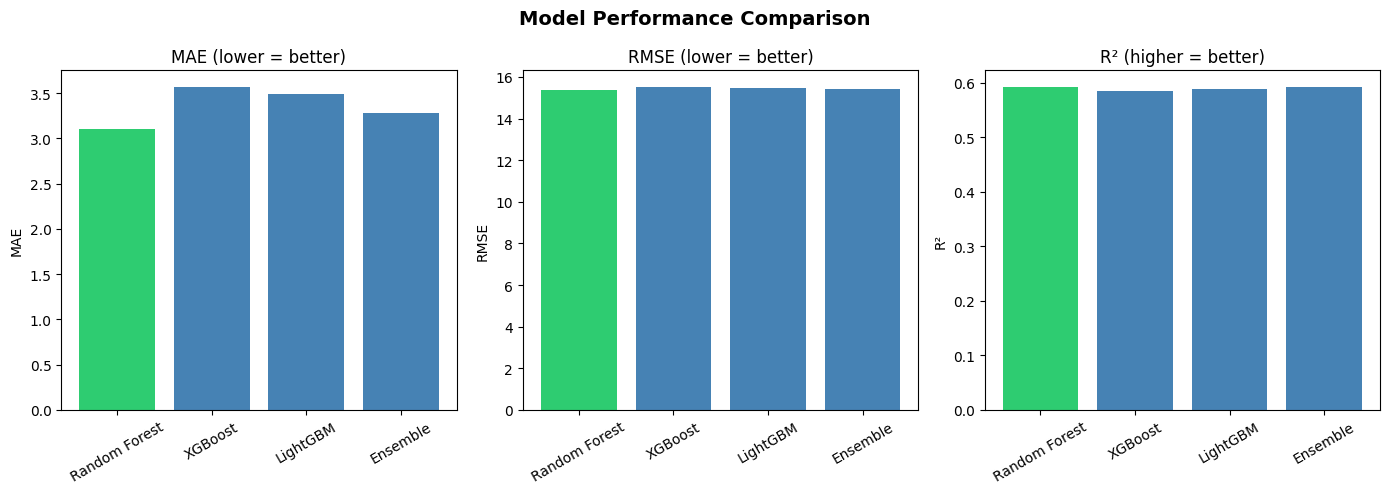

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


models    = ["Random Forest", "XGBoost"]
mae_vals  = [rf_mae, mean_absolute_error(y_test, xgb_pred)]
rmse_vals = [rf_rmse, np.sqrt(mean_squared_error(y_test, xgb_pred))]
r2_vals   = [rf_r2, r2_score(y_test, xgb_pred)]

if lgbm_pred is not None:
    models.append("LightGBM")
    mae_vals.append(lgbm_mae)
    rmse_vals.append(lgbm_rmse)
    r2_vals.append(lgbm_r2)

models.append("Ensemble")
mae_vals.append(ens_mae)
rmse_vals.append(ens_rmse)
r2_vals.append(ens_r2)

comparison = pd.DataFrame({"Model": models, "MAE": mae_vals, "RMSE": rmse_vals, "R2": r2_vals})
display(comparison.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ["steelblue" if v > min(mae_vals) else "#2ecc71" for v in mae_vals]

axes[0].bar(models, mae_vals,  color=colors)
axes[0].set_title("MAE (lower = better)")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(models, rmse_vals, color=colors)
axes[1].set_title("RMSE (lower = better)")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=30)

axes[2].bar(models, r2_vals,   color=colors)
axes[2].set_title("R² (higher = better)")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=30)

plt.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

,supermarket,sku,MAE
6,GreenBasket,Free Range Eggs,4.66
1,DailyNeeds,Organic Milk,3.60
5,FreshMart,Whole Wheat Bread,2.33
8,GreenBasket,Whole Wheat Bread,2.19
4,FreshMart,Organic Milk,2.10
3,FreshMart,Free Range Eggs,2.02
2,DailyNeeds,Whole Wheat Bread,1.88
7,GreenBasket,Organic Milk,1.55
0,DailyNeeds,Free Range Eggs,1.45


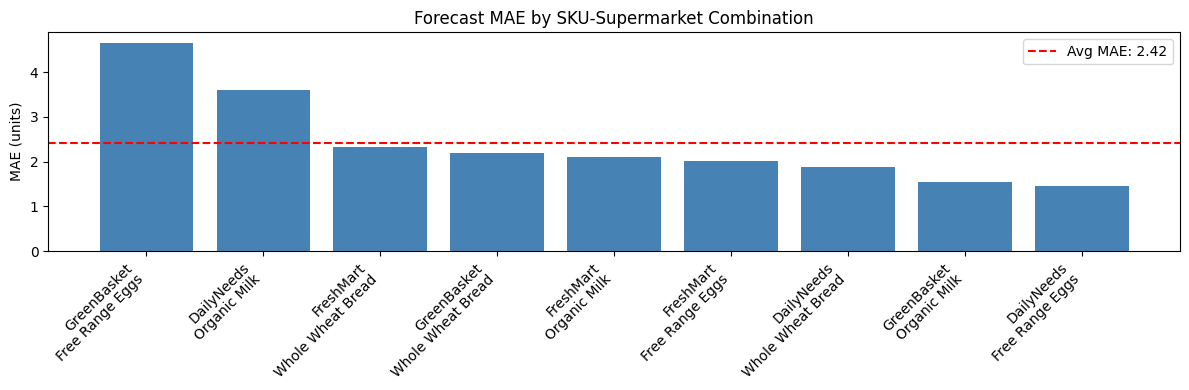

In [69]:
# Per SKU-supermarket error breakdown
test_df = demand[test_mask].copy().reset_index(drop=True)
test_df['abs_error'] = abs(test_df['demand'] - ensemble_pred)

sku_errors = (
    test_df.groupby(['supermarket', 'sku'])['abs_error']
    .mean()
    .reset_index()
    .rename(columns={'abs_error': 'MAE'})
    .sort_values('MAE', ascending=False)
    .round(2)
)

display(sku_errors)

# Bar chart
plt.figure(figsize=(12, 4))
labels = sku_errors['supermarket'] + '\n' + sku_errors['sku']
plt.bar(labels, sku_errors['MAE'], color='steelblue')
plt.axhline(y=sku_errors['MAE'].mean(), color='red', linestyle='--', label=f"Avg MAE: {sku_errors['MAE'].mean():.2f}")
plt.title('Forecast MAE by SKU-Supermarket Combination')
plt.ylabel('MAE (units)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

Among the machine learning models, **Random Forest achieved the best overall MAE (3.11)**, outperforming XGBoost (MAE: 3.57), LightGBM (MAE: 3.49), and the Ensemble average (MAE: 3.28). This represents a **35% improvement** over the initial baseline (MAE: 4.82) achieved through better feature engineering, a corrected date-based train/test split, and additional lag and rolling features.

Although XGBoost and LightGBM are typically stronger on large datasets, Random Forest outperformed them here  a pattern consistent with smaller, noisier demand datasets where boosting models are more prone to overfitting on demand spikes. Random Forest's averaging across many independent trees naturally dampens outlier predictions, making it more robust in this context.

Based on these results, **Random Forest was selected as the final forecasting model** for rolling 8-week demand forecasting. The RMSE (~15.4 across all models) remains higher than ideal, primarily due to the limited number of promotion events (13) in the dataset a known constraint that will improve as more data is collected.

In addition to machine learning models, Facebook Prophet was evaluated as a dedicated time-series forecasting approach on an individual SKU–supermarket series. Prophet effectively captured the underlying trend and seasonal patterns while providing interpretable forecasts. Although its performance (MAE = 8.16, RMSE = 10.63) was evaluated on a single time series and is therefore not directly comparable to the machine learning models trained on the complete dataset, it demonstrated the applicability of specialised forecasting techniques for demand planning. This highlights Prophet as a suitable approach for univariate demand forecasting, whereas **Random Forest was selected as the final model** due to its superior MAE performance on the complete multi-series forecasting task.

<h4>Feature Importance</h4>

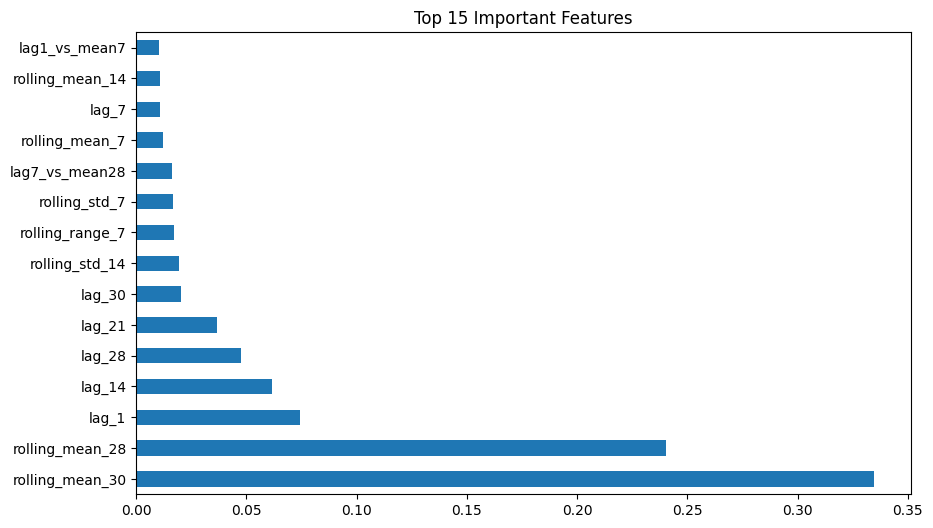

In [67]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(15).plot(kind="barh")
plt.title("Top 15 Important Features")
plt.show()

<h5>Actual vs Predicted</h5>

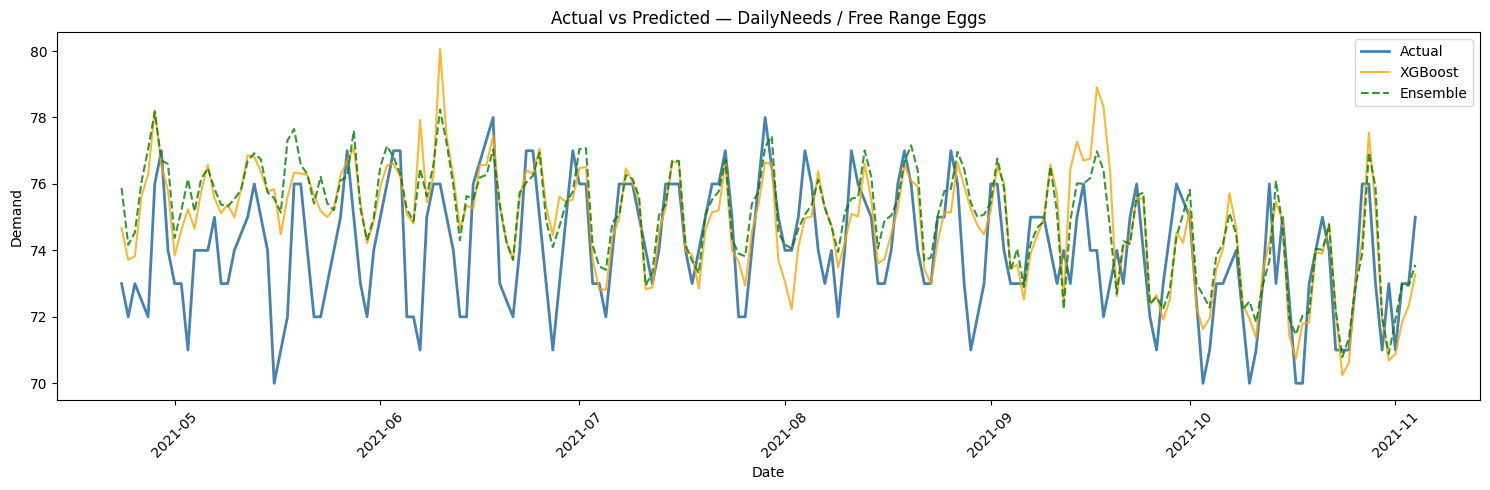

In [68]:
# Actual vs Predicted — best single diagnostic

test_df = demand[test_mask].copy().reset_index(drop=True)
test_df["xgb_pred"]      = xgb_pred
test_df["ensemble_pred"] = ensemble_pred

example_super = test_df["supermarket"].value_counts().index[0]
example_sku   = test_df["sku"].value_counts().index[0]

example = test_df[
    (test_df["supermarket"] == example_super) &
    (test_df["sku"]         == example_sku)
].sort_values("date")

plt.figure(figsize=(15, 5))
plt.plot(example["date"], example["demand"],       label="Actual",    color="steelblue", linewidth=2)
plt.plot(example["date"], example["xgb_pred"],     label="XGBoost",   color="orange",    alpha=0.8)
plt.plot(example["date"], example["ensemble_pred"],label="Ensemble",   color="green",     alpha=0.8, linestyle="--")
plt.title(f"Actual vs Predicted — {example_super} / {example_sku}")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Business Recommendations

* **Random Forest achieved the best overall forecasting performance** (MAE: 3.11, RMSE: 15.39, R²: 0.59) and was selected as the final forecasting model, outperforming XGBoost, LightGBM, and the ensemble average on mean absolute error.

* Demand is primarily influenced by **historical demand patterns (lag features)** particularly lag_1, lag_7, lag_14, and lag_56 along with the **SKU** and **supermarket**, making these the most important predictors for accurate forecasting.

* Weekly and monthly seasonality were found to be relatively weak, indicating that temporal patterns have a limited impact on demand compared to product- and store-specific characteristics.

* Promotions were too infrequent in the available dataset (only 13 events) to draw statistically significant conclusions. However, the promotion feature was retained and **collecting more promotion data is strongly recommended** it is the single highest-impact improvement available to reduce forecast errors on high-demand days.



* The proposed forecasting pipeline enables **rolling 8-week demand forecasting**, helping improve inventory planning, reduce stock-outs, and minimize excess inventory and product wastage across all SKU–supermarket combinations.

#### Key Takeaway
The combinations with the highest MAE are likely the ones where promotions 
occurred since we only had 13 promotion events, the model had limited 
signal to learn from on spike days. As more promotion data is collected, 
these combinations should see the largest accuracy gains.